In [116]:
import numpy as np
import matplotlib.pyplot as plt
from jolly_roger import tractor
import astropy.units as u

In [55]:
RNG = np.random.default_rng(1234)

In [119]:
n_delay = n_freq = 512
n_time = 1024

In [154]:
freq_chan = np.linspace(744, 1032, n_freq) * u.MHz
real_noise = RNG.normal(
    loc=1, scale=1, size=(n_time, n_freq)
)
imag_noise = RNG.normal(
    loc=1, scale=1, size=(n_time, n_freq)
)
complex_noise = real_noise + 1j * imag_noise

fake_delay_time = np.fft.fftshift(
    np.fft.fft(complex_noise, axis=1, norm="forward"), axes=1
)
fake_delay_axis = np.fft.fftshift(
    np.fft.fftfreq(
        n=len(freq_chan),
        d=np.diff(freq_chan).mean(),
    ).decompose()
)

fake_time_axis = np.linspace(0, 1, n_time)

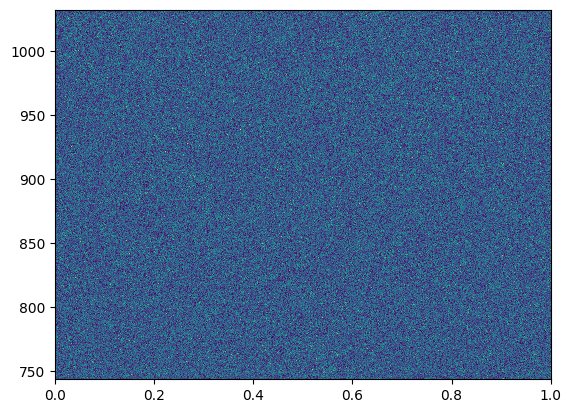

In [141]:
fig, ax = plt.subplots()
ax.pcolormesh(
    fake_time_axis,
    freq_chan.value,
    np.abs(complex_noise).T
)

In [164]:
x_grid, y_grid = np.meshgrid(fake_time_axis, fake_delay_axis.value)
amp_grid = np.zeros_like(x_grid)

amplitude = fake_delay_axis.value.max() * 0.8
height = np.linspace(0, 1, n_time)
# Sine wave parameters
frequency = 1 
phase = 0.0
thickness = 5

delay_values = amplitude * np.sin(2 * np.pi * frequency * fake_time_axis)

row_idx = np.round(
    (delay_values - fake_delay_axis.value[0])
    / (fake_delay_axis.value[-1] - fake_delay_axis.value[0])
    * (n_delay - 1)
).astype(int)

row_idx = np.clip(row_idx, 0, n_delay - 1)
for offset in range(-thickness, thickness + 1):
    rows = np.clip(row_idx + offset, 0, n_delay - 1)
    amp_grid[rows, np.arange(n_time)] += height

In [167]:
total_fake = fake_delay_time + amp_grid.T

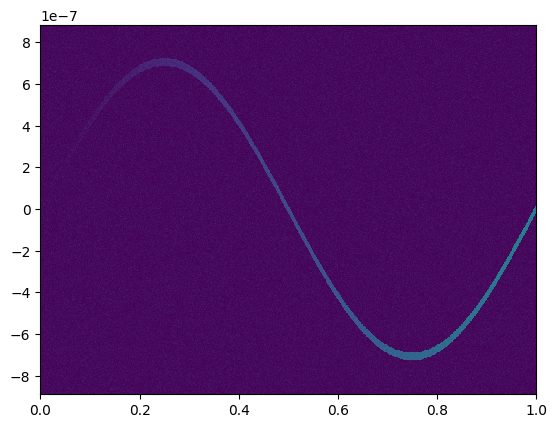

In [169]:
fig, ax = plt.subplots()
ax.pcolormesh(
    fake_time_axis,
    fake_delay_axis,
    np.abs(total_fake).T
)

In [170]:
fake_dynamic_spec = np.fft.ifft(
    np.fft.ifftshift(total_fake, axes=1),
    axis=1,
    norm="forward",
)

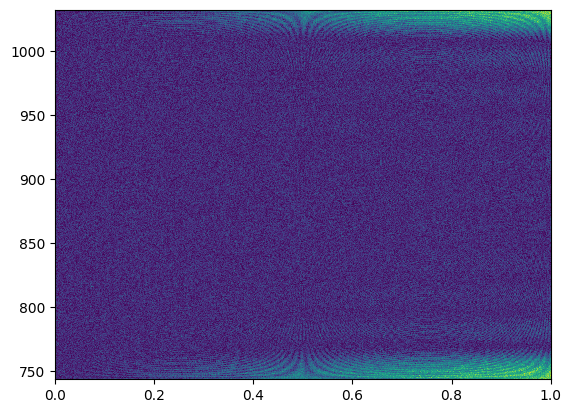

In [172]:
fig, ax = plt.subplots()
ax.pcolormesh(
    fake_time_axis,
    freq_chan.value,
    np.abs(fake_dynamic_spec).T
)

In [175]:
fake_dynamic_spec[..., None].repeat(4, axis=-1).shape

(1024, 512, 4)

In [ ]:
from dataclasses import dataclass
from astropy.coordinates import SkyCoord
from astropy.time import Time
from numpy.typing import NDArray
from typing import Any

@dataclass
class DataOnlyChunk:
    """Container for a collection of data and associated metadata.
    Here data are drawn from a series of rows.
    """

    masked_data: np.ma.MaskedArray
    """The baseline data, masked where flags are set. shape=(time, chan, pol)"""
    freq_chan: u.Quantity
    """The frequency channels corresponding to the data."""
    phase_center: SkyCoord
    """The target sky coordinate for the baseline."""
    uvws_phase_center: u.Quantity
    """The UVW coordinates of the phase center of the baseline."""
    time: Time
    """The time of the observations."""
    time_mjds: NDArray[np.floating[Any]]
    """The raw time extracted from the measurement set in MJDs"""
    ant_1: NDArray[np.int64]
    """The first antenna in the baseline."""
    ant_2: NDArray[np.int64]
    """The second antenna in the baseline."""


In [ ]:
data_chunk = tractor.DataChunk(
    masked_data=np.ma.MaskedArray(
        data=fake_dynamic_spec[..., None].repeat(4, axis=-1)
    ),
    freq_chan=freq_chan,
    
)

TypeError: DataChunk.__init__() missing 9 required positional arguments: 'freq_chan', 'phase_center', 'uvws_phase_center', 'time', 'time_mjds', 'ant_1', 'ant_2', 'row_start', and 'chunk_size'